Performed an Exploratory Data Analysis (EDA) on a large banking dataset (500,000+ records) to identify the target market for a new credit card launch. Cleaned and validated the data, handled missing values and outliers, conducted credit score and correlation analyses, and visualized customer behavior and spending patterns to uncover key insights.

Designed and implemented an A/B testing framework to evaluate the effectiveness of the **new credit card launch**, applying statistical hypothesis testing, Z-tests, and confidence interval analysis to measure the impact on average transaction amounts.

The analysis identified the **18–25 age group as a high-potential target segment**, and the A/B test results showed a **statistically significant increase in average transaction amounts**, supporting a data-driven launch strategy for the new credit card product.


In [102]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm

In [2]:
df_cust = pd.read_csv('/Users/mustafafarooqui/DS Projects/AtliQo Bank Project /dataset/customers.csv')
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [3]:
# Checking size and datatypes of dataframe

df_cust.shape

(1000, 8)

In [4]:
df_cust.dtypes

cust_id             int64
name               object
gender             object
age                 int64
location           object
occupation         object
annual_income     float64
marital_status     object
dtype: object

In [5]:
# quick stats

df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [6]:
# checking for duplicate rows if any

df_cust.duplicated().sum()

np.int64(0)

In [7]:
df_cust['cust_id'].duplicated().sum()

np.int64(0)

In [8]:
# Checking the null values from each column

df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [9]:
df_cust[df_cust['annual_income'].isnull()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


In [10]:
# Null values treatment in annual_income column

# note:- Replaceing the Null values with appropriate medians of their occupations

occ_wise_income_median = df_cust.groupby('occupation')['annual_income'].median()
occ_wise_income_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [11]:
df_cust['annual_income'] = df_cust['annual_income'].fillna(
    df_cust['occupation'].map(occ_wise_income_median)
)

In [12]:
# conforming the transformation

df_cust[df_cust['annual_income'].isnull()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [13]:
df_cust.iloc[[14, 82, 97, 107, 102, 155]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,261191.5,Married
107,108,Advait Lal,Female,46,Suburb,Consultant,20188.0,Single
102,103,Pooja Ganguly,Male,32,City,Data Scientist,135759.0,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,76774.0,Married


In [14]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

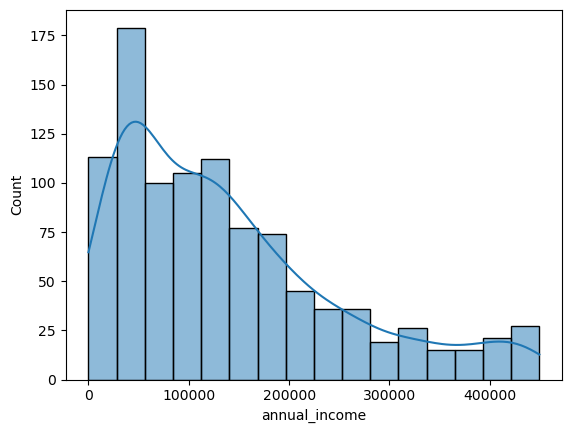

In [15]:
# Annual income distribution

sns.histplot(df_cust['annual_income'], kde=True)
plt.show()

# Note:- Distribution is right-skewed. Income naturally varies by occupation

In [16]:
# Outliers working for annual_income colum

# Note:- Values of annual_income < 100 are treated as outliers and imputed using occupation medians.

df_cust['annual_income'] = df_cust['annual_income'].mask(
    df_cust['annual_income'] < 100,
    df_cust['occupation'].map(occ_wise_income_median)
)
df_cust['annual_income'].describe()

count      1000.000000
mean     140483.548500
std      110463.002934
min        5175.000000
25%       49620.500000
50%      115328.000000
75%      195514.250000
max      449346.000000
Name: annual_income, dtype: float64

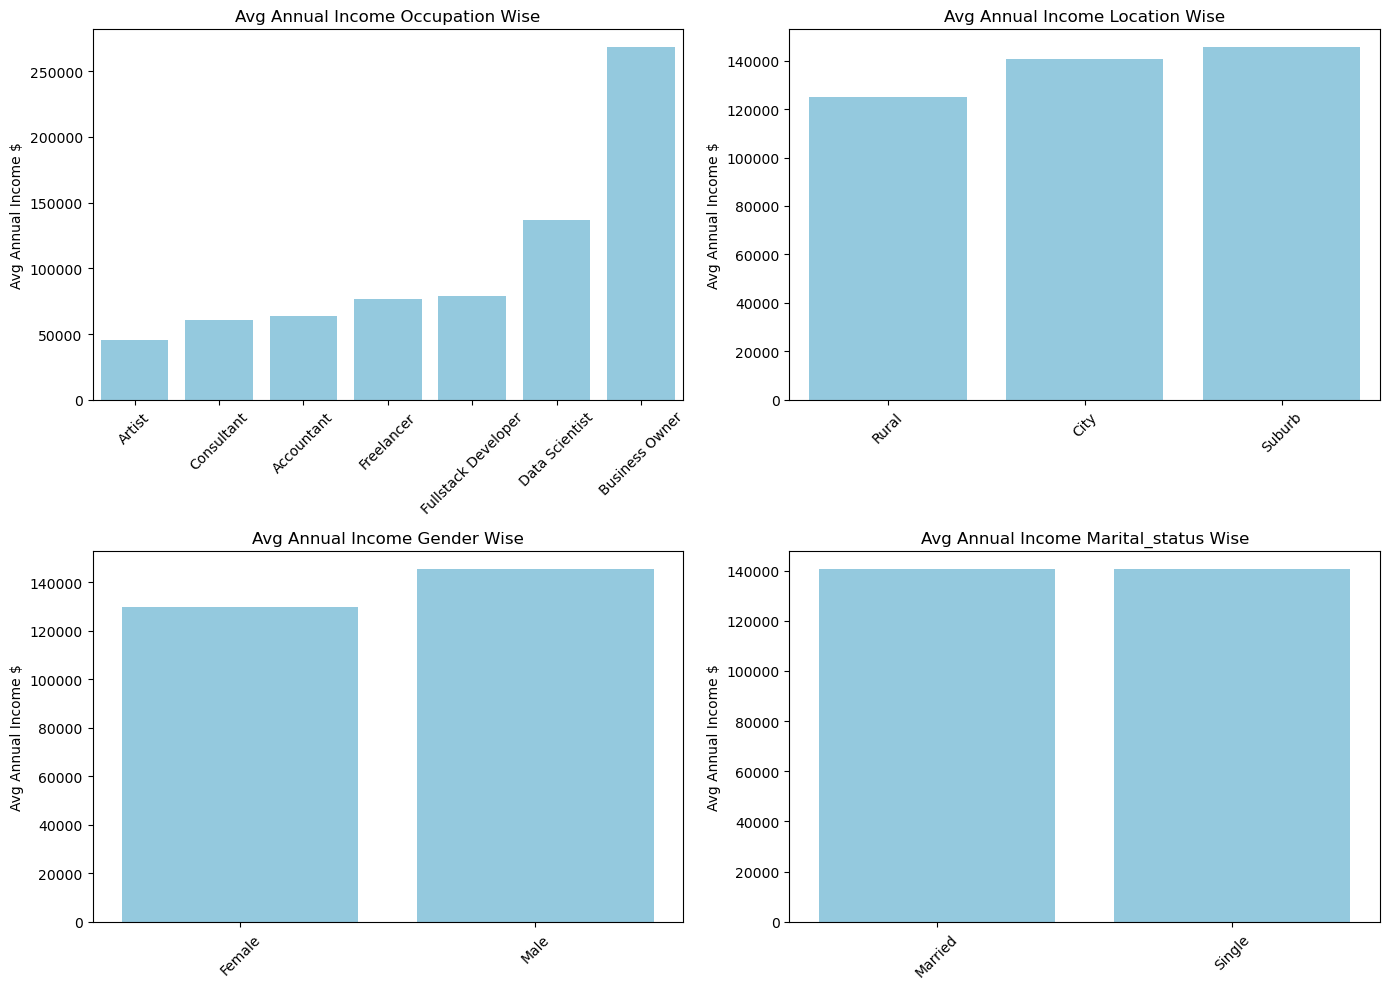

In [17]:
# Income insights and visulizations

categorical_columns = ['occupation', 'location', 'gender', 'marital_status']

# Creating  a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2 rows x 2 cols
axes = axes.flatten()  # flatten to iterate easily

for i, cat in enumerate(categorical_columns):
    avg_income_per_cat = df_cust.groupby(cat)['annual_income'].mean().sort_values()
    sns.barplot(
        x=avg_income_per_cat.index,
        y=avg_income_per_cat.values,
        color='skyblue',
        ax=axes[i]  # plot on the subplot
    )
    axes[i].set_title(f'Avg Annual Income {cat.capitalize()} Wise')
    axes[i].set_xlabel('')  # remove automatic x-label
    axes[i].set_ylabel('Avg Annual Income $')
    axes[i].tick_params(axis='x', rotation=45)  # rotate x-ticks

plt.tight_layout()  # adjust spacing
plt.show()

In [18]:
# Outliers treatment for age column

# Note:- Age is valid only if it is between 15 and 80 years.if it's not then imputed using occupation wise median age

occ_wise_age_median = df_cust.groupby('occupation')['age'].median().astype(int).sort_values()
occ_wise_age_median 

occupation
Freelancer             24
Artist                 26
Fullstack Developer    27
Accountant             31
Data Scientist         32
Consultant             46
Business Owner         51
Name: age, dtype: int64

In [19]:
df_cust['age'] = np.where(
    (df_cust['age'] < 15) | (df_cust['age'] > 80),
    df_cust['occupation'].map(occ_wise_age_median).astype(int),
    df_cust['age']
)
df_cust['age'].describe()

count    1000.000000
mean       35.539000
std        12.277998
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

In [20]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [21]:
# Creating Age Groups and finding it's distribution

df_cust['age_group'] = pd.cut(
    df_cust['age'],
    bins=[17, 25, 48, 65],
    labels=['18-25', '26-48', '49-65']
)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48


In [22]:
age_groups = df_cust['age_group'].value_counts(normalize=True)*100.
age_groups

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

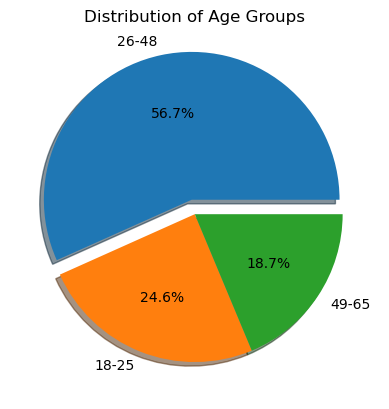

In [23]:
plt.pie(
    age_groups, labels=age_groups.index,
    shadow=True, autopct="%0.1f%%", explode=(0.1, 0, 0)
)
plt.title('Distribution of Age Groups')
plt.show()

In [24]:
# Gender Wise Customer Distribution Across locations

df_cust.groupby(['location', 'gender']).size()

location  gender
City      Female    226
          Male      457
Rural     Female     26
          Male       59
Suburb    Female     74
          Male      158
dtype: int64

In [25]:
gender_wise_location = df_cust.groupby(['location', 'gender']).size().unstack()
gender_wise_location

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


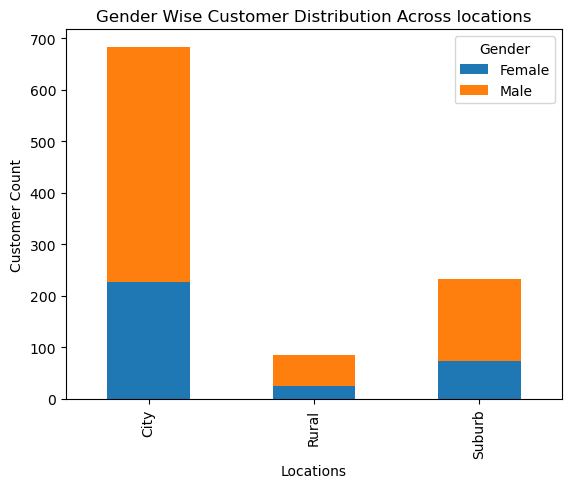

In [26]:
gender_wise_location.plot(kind='bar', stacked=True)
plt.title('Gender Wise Customer Distribution Across locations')
plt.xlabel('Locations')
plt.legend(title='Gender')
plt.ylabel('Customer Count')
plt.show()

Working with credit profile data set

In [27]:
df_cs = pd.read_csv('/Users/mustafafarooqui/DS Projects/AtliQo Bank Project /dataset/credit_profiles.csv')
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [28]:
df_cs.dtypes

cust_id                             int64
credit_score                        int64
credit_utilisation                float64
outstanding_debt                  float64
credit_inquiries_last_6_months    float64
credit_limit                      float64
dtype: object

In [29]:
df_cs.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 4
outstanding_debt                   4
credit_inquiries_last_6_months     4
credit_limit                      69
dtype: int64

In [30]:
df_cs.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1004.000000,1004.000000,1000.000000,1000.000000,1000.000000,935.000000
mean,500.850598,588.655378,0.498950,9683.597000,1.955000,19235.561497
std,288.315670,152.575244,0.233139,25255.893671,1.414559,24489.997195
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,251.750000,459.000000,0.293917,221.000000,1.000000,750.000000
50%,502.500000,601.000000,0.487422,550.000000,2.000000,1250.000000
75%,749.250000,737.250000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


In [31]:
df_cs.shape

(1004, 6)

In [32]:
# Checking for dupliate rows if any .This checks the entire row duplicacy 

df_cs.duplicated().sum()

np.int64(0)

In [33]:
# This check dublicates in a specific column

df_cs['cust_id'].duplicated().sum()

np.int64(4)

In [34]:
df_cs[df_cs['cust_id'].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [35]:
# Keeping the rows which has less NAN values

df_cs = df_cs.drop_duplicates(subset='cust_id', keep='last')

In [36]:
df_cs.shape

(1000, 6)

In [37]:
df_cs['cust_id'].duplicated().sum()

np.int64(0)

In [38]:
df_cs.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

Credit limit coloum has null values 

In [39]:
# Treatment

df_cs[df_cs['credit_limit'].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [40]:
df_cs.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,935.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19235.561497
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24489.997195
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1250.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


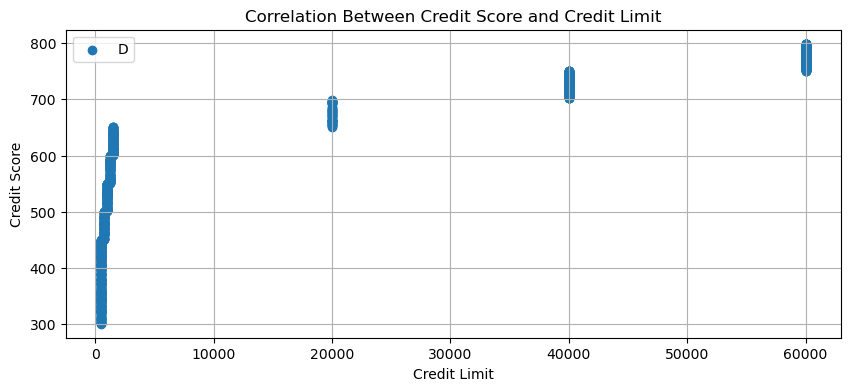

In [41]:
plt.figure(figsize=(10, 4))
plt.scatter(df_cs['credit_limit'], df_cs['credit_score'])
plt.title('Correlation Between Credit Score and Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')
plt.legend('D')
plt.grid(True)
plt.show()

We observed a strong positive correlation between credit_score and credit_limit from the scatter plot.  
To maintain this relationship, we will fill the missing values in the `credit_limit` column using the median credit limit corresponding to each credit score.  
This ensures that the imputed values are realistic and consistent with the observed trend in the data.

In [42]:
# Grouping the credit limits into categories for null values treatment

bins = [299, 499, 649, 749, 799]

labels = ['Poor', 'Fair', 'Good', 'Excellent']
df_cs['cs_bucket'] = pd.cut(df_cs['credit_score'], bins=bins, labels=labels)

df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
0,1,749,0.585171,19571.0,0.0,40000.0,Good
1,2,587,0.107928,161644.0,2.0,1250.0,Fair
2,3,544,0.854807,513.0,4.0,1000.0,Fair
3,4,504,0.336938,224.0,2.0,1000.0,Fair
4,5,708,0.586151,18090.0,2.0,40000.0,Good


In [43]:
df_cs[df_cs['credit_limit'].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
10,11,679,0.557450,9187.0,2.0,NaN,Good
35,36,790,0.112535,4261.0,1.0,NaN,Excellent
37,38,514,0.296971,238.0,2.0,NaN,Fair
45,46,761,0.596041,24234.0,2.0,NaN,Excellent
64,65,734,0.473715,13631.0,0.0,NaN,Good
...,...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN,Poor
931,928,311,0.832244,316.0,2.0,NaN,Poor
948,945,526,0.272734,227.0,1.0,NaN,Fair
954,951,513,0.175914,131.0,3.0,NaN,Fair


In [44]:
cs_bucket_wise_median = df_cs.groupby('cs_bucket', observed=True)['credit_limit'].median()
cs_bucket_wise_median

cs_bucket
Poor           500.0
Fair          1250.0
Good         40000.0
Excellent    60000.0
Name: credit_limit, dtype: float64

In [45]:
df_cs['credit_limit'] = df_cs['credit_limit'].fillna(
    df_cs['cs_bucket'].map(cs_bucket_wise_median).astype(float)
)

# Double Checking

df_cs.loc[[10, 35, 37, 45, 64]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
10,11,679,0.557450,9187.0,2.0,40000.0,Good
35,36,790,0.112535,4261.0,1.0,60000.0,Excellent
37,38,514,0.296971,238.0,2.0,1250.0,Fair
45,46,761,0.596041,24234.0,2.0,60000.0,Excellent
64,65,734,0.473715,13631.0,0.0,40000.0,Good


In [46]:
df_cs.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
cs_bucket                         0
dtype: int64

In [47]:
df_cs.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19753.250000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24726.133617
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1250.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


Outlier Treatment for Outstanding debt coloumn. Any value greater than credit limit is a obvious outlier

In [48]:
df_cs[(df_cs['outstanding_debt']) > (df_cs['credit_limit'])]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
1,2,587,0.107928,161644.0,2.0,1250.0,Fair
19,20,647,0.439132,205014.0,3.0,1500.0,Fair
25,26,758,0.250811,190838.0,2.0,60000.0,Excellent
38,39,734,0.573023,122758.0,3.0,40000.0,Good
93,94,737,0.739948,137058.0,2.0,40000.0,Good
204,205,303,0.364360,187849.0,0.0,500.0,Poor
271,272,703,0.446886,154568.0,1.0,40000.0,Good
301,302,722,0.608076,122402.0,4.0,40000.0,Good
330,331,799,0.363420,208898.0,4.0,60000.0,Excellent
350,351,320,0.285081,150860.0,0.0,500.0,Poor


In [49]:
# Treatment 
df_cs['outstanding_debt'] = np.where(
    df_cs['outstanding_debt'] > df_cs['credit_limit'],
    df_cs['credit_limit'], df_cs['outstanding_debt']
)

In [50]:
# Double Checking
df_cs[(df_cs['outstanding_debt']) > (df_cs['credit_limit'])]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket


In [51]:
df_cs.loc[[1, 19, 25, 38]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
1,2,587,0.107928,1250.0,2.0,1250.0,Fair
19,20,647,0.439132,1500.0,3.0,1500.0,Fair
25,26,758,0.250811,60000.0,2.0,60000.0,Excellent
38,39,734,0.573023,40000.0,3.0,40000.0,Good


In [52]:
df_cs.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19753.250000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24726.133617
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1250.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.000000


In [53]:
# Finding corelation among possible credit profile variables

df_merged = df_cust.merge(df_cs, on='cust_id', how='inner')
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,Good
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,Fair
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,Fair
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,Fair
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,Good


In [54]:
numeric_col = [
            'annual_income', 'credit_score',
            'credit_utilisation', 'outstanding_debt',
            'credit_inquiries_last_6_months', 'credit_limit',
            'age'
]
corr_matrix = df_merged[numeric_col].corr()
corr_matrix

,annual_income,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,age
annual_income,1.000000,0.575751,-0.086368,0.555661,0.002747,0.684099,0.619103
credit_score,0.575751,1.000000,-0.070445,0.680654,-0.001226,0.848115,0.444961
credit_utilisation,-0.086368,-0.070445,1.000000,0.192838,-0.013952,-0.080308,-0.027828
outstanding_debt,0.555661,0.680654,0.192838,1.000000,0.019793,0.810484,0.444375
credit_inquiries_last_6_months,0.002747,-0.001226,-0.013952,0.019793,1.000000,0.014800,-0.025806
credit_limit,0.684099,0.848115,-0.080308,0.810484,0.014800,1.000000,0.511217
age,0.619103,0.444961,-0.027828,0.444375,-0.025806,0.511217,1.000000


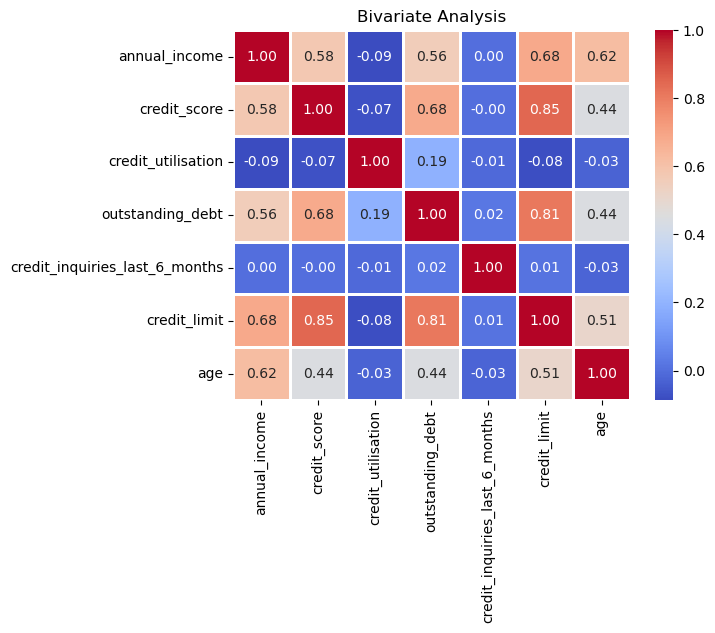

In [55]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.9)
plt.title('Bivariate Analysis')
plt.show()

Working With transaction data set.

In [56]:
df_trnsc = pd.read_csv(
    '/Users/mustafafarooqui/DS Projects/AtliQo Bank Project /dataset/transactions.csv'
)
df_trnsc.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [57]:
df_trnsc.shape

(500000, 7)

In [58]:
df_trnsc.dtypes

tran_id              int64
cust_id              int64
tran_date           object
tran_amount          int64
platform            object
product_category    object
payment_type        object
dtype: object

In [59]:
df_trnsc.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [60]:
# Treating Null values in platform column

df_trnsc[df_trnsc['platform'].isnull()].head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe


In [61]:
df_trnsc['platform'].value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

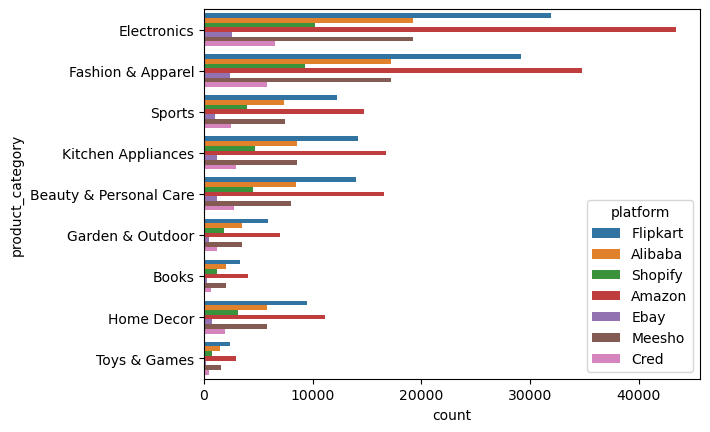

In [62]:
sns.countplot(data=df_trnsc, y='product_category', hue='platform')
plt.show()

Note:- As Amazon showed to be  most frequently used platform across all product categories. Null values in the platform column were imputed by Amazon 

In [63]:
most_frequent_pltfrm = df_trnsc['platform'].mode()[0]
df_trnsc['platform'] = df_trnsc['platform'].fillna(most_frequent_pltfrm)
df_trnsc.loc[[355, 418, 607]]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,Amazon,Electronics,Net Banking
418,419,383,2023-01-01,338,Amazon,Electronics,Credit Card
607,608,421,2023-01-01,700,Amazon,Electronics,Phonepe


In [64]:
df_trnsc.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

In [65]:
df_trnsc.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711634,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [66]:
# Outlier Treatment for tran_amount Column

zero_amount_trnsc = df_trnsc[df_trnsc['tran_amount'] == 0]
zero_amount_trnsc

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499326,499327,695,2023-09-05,0,Amazon,Electronics,Credit Card
499494,499495,295,2023-09-05,0,Amazon,Electronics,Credit Card
499708,499709,141,2023-09-05,0,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [67]:
# Exploring 

zero_amount_trnsc[['platform', 'product_category', 'payment_type']].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

All transaction amounts of zero are from the Amazon platform, in the Electronics category, and with Credit Card as the payment type.
These zero values were replaced with the median transaction amount for Amazon Electronics

In [68]:
median_to_replace = df_trnsc[
       (df_trnsc['tran_amount'] >0) & 
       (df_trnsc['product_category'] == 'Electronics') & 
       (df_trnsc['payment_type'] == 'Credit Card') &
       (df_trnsc['platform'] == 'Amazon')
]
median_value = median_to_replace['tran_amount'].median()

In [69]:
df_trnsc['tran_amount'] = df_trnsc['tran_amount'].replace(0, median_value)

In [70]:
df_trnsc.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711634,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


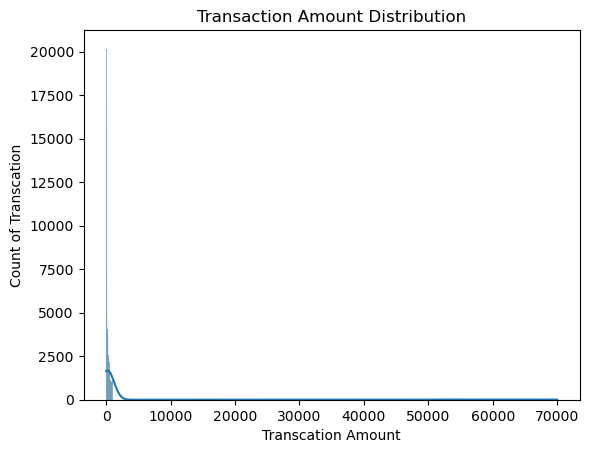

In [71]:
sns.histplot(df_trnsc['tran_amount'], kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transcation Amount')
plt.ylabel('Count of Transcation')
plt.show()

The transaction amount distribution is highly right-skewed, indicating the presence of extreme values. As the data is not normally distributed, standard deviation–based outlier methods are not appropriate; therefore, the IQR approach is adopted.

Due to varying pricing behavior across product categories, applying a global IQR is not ideal. Instead, extreme values are capped using a 2 × IQR threshold (based on business requirements), and values exceeding this cap are replaced with the median transaction amount of the respective product category. This ensures realistic, category-specific, and business-aligned outlier treatment while preserving legitimate high-value transactions.

The lower bound is not considered, as the minimum transaction amount in the dataset is 2 after handling zero-value transactions, indicating no meaningful lower-end outliers.

In [72]:
Q1, Q3 = df_trnsc['tran_amount'].quantile([0.25, 0.75])

IQR = Q3 - Q1

lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

lower_bound, upper_bound

(-628.0, 1107.0)

In [73]:
outliers_trnsc_df =  df_trnsc[df_trnsc['tran_amount']>upper_bound]
outliers_trnsc_df

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [74]:
normal_trnsc_df = df_trnsc[df_trnsc['tran_amount'] < upper_bound]
normal_trnsc_df

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking
...,...,...,...,...,...,...,...
499994,499995,679,2023-09-05,59,Ebay,Beauty & Personal Care,Gpay
499995,499996,791,2023-09-05,43,Amazon,Books,Phonepe
499997,499998,57,2023-09-05,224,Amazon,Garden & Outdoor,Phonepe
499998,499999,629,2023-09-05,538,Flipkart,Home Decor,Gpay


In [75]:
category_wise_median_amt = normal_trnsc_df.groupby('product_category')['tran_amount'].median()
category_wise_median_amt

product_category
Beauty & Personal Care     92.0
Books                      30.0
Electronics               529.0
Fashion & Apparel          65.0
Garden & Outdoor          126.0
Home Decor                305.0
Kitchen Appliances        176.0
Sports                    269.0
Toys & Games               50.0
Name: tran_amount, dtype: float64

In [76]:
df_trnsc['tran_amount'] = np.where(
    df_trnsc['tran_amount'] > upper_bound, 
    df_trnsc['product_category'].map(category_wise_median_amt), 
    df_trnsc['tran_amount']
)

In [77]:
df_trnsc.loc[[26, 49, 94, 104, 113]]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.0,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.0,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.0,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,65.0,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.0,Shopify,Kitchen Appliances,Credit Card


In [78]:
df_trnsc.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking


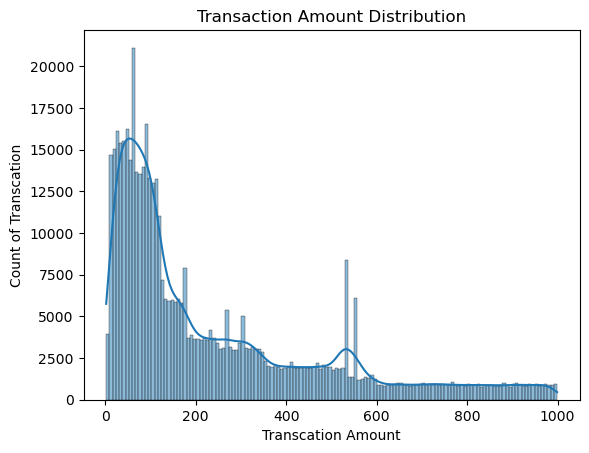

In [79]:
sns.histplot(df_trnsc['tran_amount'], kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transcation Amount')
plt.ylabel('Count of Transcation')
plt.show()

In [80]:
# Insights and visualizations.

df_merged_2 = pd.merge(df_merged, df_trnsc, on='cust_id', how='inner')
df_merged_2.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,Good,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,Good,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,Good,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,Good,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,Good,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


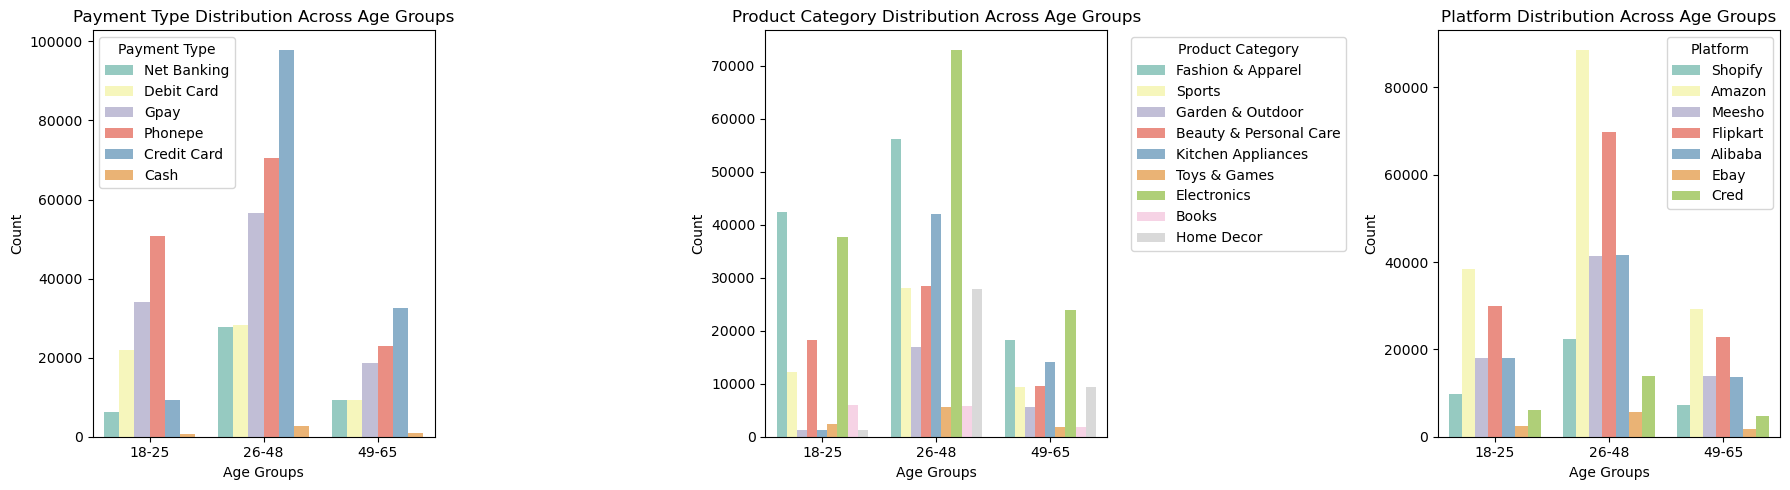

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Payment Type Distribution Across Age Groups
sns.countplot(
    data=df_merged_2,
    x='age_group',
    hue='payment_type',
    palette='Set3',
    ax=axes[0]
)
axes[0].set_title('Payment Type Distribution Across Age Groups')
axes[0].set_xlabel('Age Groups')
axes[0].set_ylabel('Count')
axes[0].legend(title='Payment Type')

# Plot 2: Product Category Distribution Across Age Groups
sns.countplot(
    data=df_merged_2,
    x='age_group',
    hue='product_category',
    palette='Set3',
    ax=axes[1]
)
axes[1].set_title('Product Category Distribution Across Age Groups')
axes[1].set_xlabel('Age Groups')
axes[1].set_ylabel('Count')
axes[1].legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Platform Distribution Across Age Groups
sns.countplot(
    data=df_merged_2,
    x='age_group',
    hue='platform',
    palette='Set3',
    ax=axes[2]
)
axes[2].set_title('Platform Distribution Across Age Groups')
axes[2].set_xlabel('Age Groups')
axes[2].set_ylabel('Count')
axes[2].legend(title='Platform')

plt.tight_layout()
plt.show()

Credit card usage is relatively low among the 18–25 age group, with spending largely concentrated in the Fashion & Apparel category. In contrast, the 26–48 age group exhibits the highest credit card usage, followed by the 49–65 group, where Electronics is the most prominent spending category. Additionally, Amazon emerges as the most frequently used platform across all age groups.

In [82]:
age_groups_mertrics = df_merged_2.groupby('age_group', observed=True)[['annual_income', 'credit_score', 'credit_limit']].mean()
age_groups_mertrics.reset_index()

,age_group,annual_income,credit_score,credit_limit
0,18-25,37138.181054,484.708344,1132.927655
1,26-48,146092.690672,597.918043,20645.368057
2,49-65,260430.658253,701.876810,41783.002349


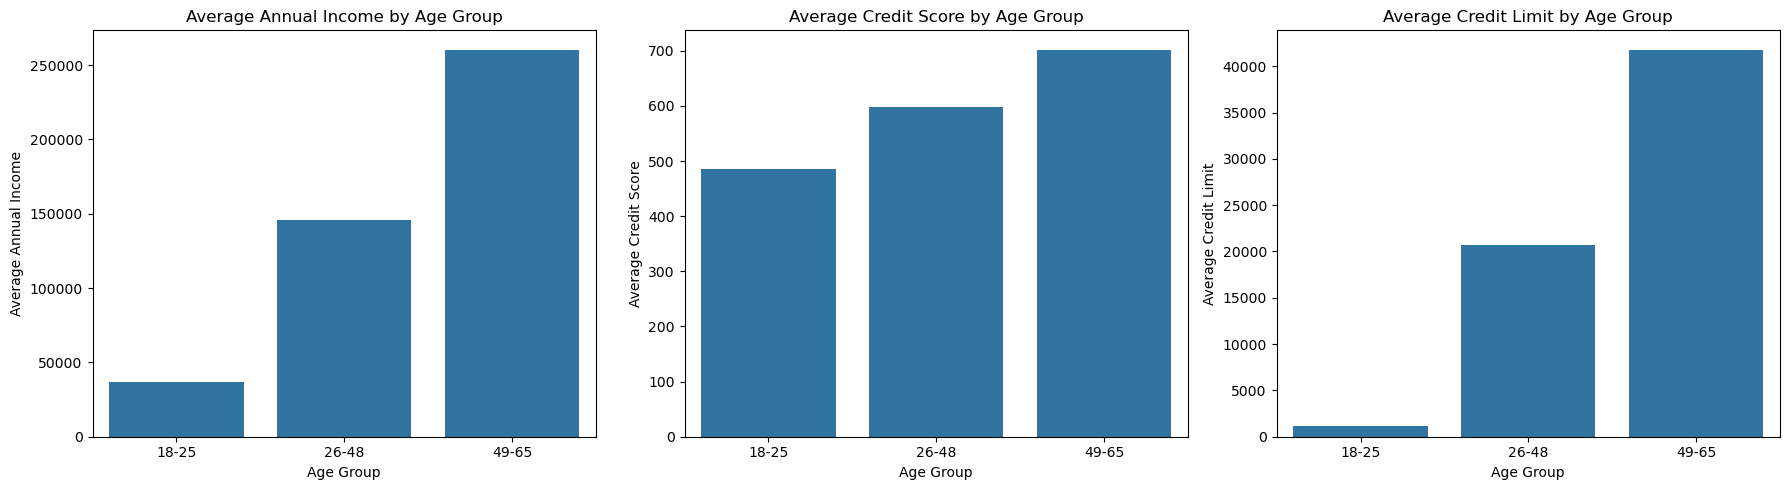

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color = sns.color_palette('tab10')[0]

# Plot 1: Annual Income
sns.barplot(
    data=age_groups_mertrics,
    x='age_group',
    y='annual_income',
    color=color,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title('Average Annual Income by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Annual Income')

# Plot 2: Credit Score
sns.barplot(
    data=age_groups_mertrics,
    x='age_group',
    y='credit_score',
    color=color,
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title('Average Credit Score by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Credit Score')

# Plot 3: Credit Limit
sns.barplot(
    data=age_groups_mertrics,
    x='age_group',
    y='credit_limit',
    color=color,
    errorbar=None,
    ax=axes[2]
)
axes[2].set_title('Average Credit Limit by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Average Credit Limit')

plt.tight_layout()
plt.show()


# Business Analysis and A/B Test Launch: Targeting the 18–25 Segment

## Market Opportunity Identification

An exploratory data analysis was conducted to identify potential growth opportunities within the customer base. The 18–25 age group emerged as a high-potential yet underpenetrated segment based on the following insights:

### Key Insights for Age Group 18–25

- Customers aged **18–25 represent approximately 25%** of the total customer base.
- The **average annual income** of this segment is below **$50,000**, indicating early-career or student profiles.
- Limited credit history is reflected in:
  - Lower average credit scores
  - Lower maximum credit limits
- Credit card usage as a payment method is relatively low compared to older age groups.
- The **average transaction amount using credit cards** is also lower than other segments.
- Top 3 spending categories:
  - Fashion & Apparel  
  - Electronics  
  - Beauty & Personal Care  

## Business Hypothesis

Given the significant size of this segment and its relatively low credit card engagement, a targeted credit card offering tailored to their spending behavior may increase adoption and transaction amounts.

To evaluate this hypothesis, an A/B testing framework was designed to measure the impact of launching a new credit card product for this age group.


(# Pre-Campaign Planning

We plan to conduct a trial run for the launch of our new credit card product.  
Before initiating the campaign, it is essential to design a statistically sound A/B testing framework.

## 1. Sample Size Determination

To evaluate the effectiveness of the new credit card, we will form two groups:

- **Test Group** – Customers who will receive the new credit card offer.
- **Control Group** – Customers who will not receive the offer and will continue with existing products.

The required number of customers in each group will be determined using **power analysis**.  

The sample size calculation will be based on:

- **Statistical Power (e.g., 80%)** – Probability of correctly detecting a true effect.
- **Significance Level (α, e.g., 0.05)** – Acceptable probability of Type I error.
- **Minimum Detectable Effect Size** – The smallest meaningful increase in average transaction amount agreed upon with business stakeholders.

These parameters will be finalized in consultation with the business team to ensure that the experiment is both statistically robust and commercially meaningful.


In [84]:
alpha = 0.05
power = 0.80
effect_size = 0.2

sms.tt_ind_solve_power(alpha=alpha, power=power, effect_size=effect_size , ratio=1.0, alternative='two-sided')

393.4056930002514


## Effect Size and Sample Size Considerations

Based on the initial power analysis:

- For a **minimum detectable effect size of 0.2 (small effect)**,
- At a significance level of 5% (α = 0.05),
- With statistical power of 80%,

We would require approximately **393 customers per group** to reliably detect such an effect.

However, it is important to consider **budgetary and operational constraints** while designing the campaign. A larger sample size increases statistical precision but also raises campaign costs.

Therefore, we will evaluate required sample sizes across multiple effect sizes (e.g., 0.2, 0.3, 0.4, etc.) and discuss trade-offs with business stakeholders to determine:

- The **minimum effect size that is commercially meaningful**, and  
- The **optimal sample size** that balances statistical reliability with budget limitations.

The final experiment design will be selected based on this joint statistical and business evaluation.


In [85]:
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(
        alpha=0.05, 
        power=0.80, 
        effect_size=effect_size,
        alternative='two-sided',
        ratio=1
    )
    print(f'Effect size :- {effect_size}, Required sample:- {int(sample_size)} ')

Effect size :- 0.1, Required sample:- 1570 
Effect size :- 0.2, Required sample:- 393 
Effect size :- 0.3, Required sample:- 175 
Effect size :- 0.4, Required sample:- 99 
Effect size :- 0.5, Required sample:- 63 
Effect size :- 0.6, Required sample:- 44 
Effect size :- 0.7, Required sample:- 33 
Effect size :- 0.8, Required sample:- 25 
Effect size :- 0.9, Required sample:- 20 
Effect size :- 1, Required sample:- 16 


### Effect Size Justification

With **40 customers per group**, the pilot can detect an effect size of ~**0.6** (medium-to-large).  

This is appropriate because:

- The new credit card is expected to generate **noticeable increases in spending**.  
- **Smaller effects** may not justify the campaign cost or a population-level launch.  
- A medium-to-large effect ensures the pilot provides **actionable insights** for future scaling.


In [86]:
df_merged['age_group'].value_counts()

age_group
26-48    567
18-25    246
49-65    187
Name: count, dtype: int64

# A/B Test Design: New Credit Card Launch

From a pool of 246 customers aged 18–25, **80 customers** will be randomly selected for the A/B test and assigned into two groups:

- **Test Group (40 customers):** Offered the newly launched credit card.  
- **Control Group (40 customers):** Not offered the new card and continue using existing credit cards.

**Campaign Duration:** 2 months (09-10-25 to 11-10-25)

**During the Campaign:**

- Test group customers may choose to accept or reject the offer.  
- Control group customers continue their usual spending behavior.

**Post-Campaign Analysis:**

- Collect transaction data for all 80 customers.  
- Compute **average transaction amount per customer** over the campaign period.

**Key Performance Indicator (KPI):**

- Assess whether offering the new credit card leads to a **statistically significant increase** in average transaction amounts compared to the control group.


# Statistical Framework

**Null Hypothesis (H₀):**  
The average transaction amount of the **test group** is less than or equal to that of the **control group**.

**Alternative Hypothesis (H₁):**  
The average transaction amount of the **test group** is greater than that of the **control group**.

**Analysis Method:**  
A **one-sided independent two-sample t-test** will be conducted to evaluate statistical significance.


In [87]:
# working 

target_age_group = df_merged[df_merged['age_group'] == '18-25'].reset_index()
target_age_group.head()

,index,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
0,2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,Fair
1,3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,Fair
2,5,6,Aditi Kaul,Male,22,City,Freelancer,44887.0,Married,18-25,442,0.705409,246.0,4.0,500.0,Poor
3,8,9,Simran Naidu,Male,21,Suburb,Fullstack Developer,34814.0,Single,18-25,537,0.448924,341.0,0.0,1000.0,Fair
4,9,10,Rishabh Bhat,Male,25,Rural,Freelancer,39832.0,Married,18-25,567,0.533402,522.0,0.0,1250.0,Fair


In [88]:
# Randomly shuffle the dataframe and pick first 80 rows

sample_df = target_age_group.sample(n=80, random_state=42)
print(sample_df.shape)
sample_df.head()

(80, 16)


,index,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
33,134,135,Aarya Goswami,Female,22,City,Freelancer,36816.0,Single,18-25,594,0.130223,95.0,2.0,1250.0,Fair
6,14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married,18-25,640,0.349837,366.0,3.0,1500.0,Fair
181,771,772,Virat Gavaskar,Male,18,Suburb,Freelancer,45041.0,Married,18-25,419,0.599732,246.0,4.0,500.0,Poor
86,362,363,Kavya Singh,Male,20,City,Fullstack Developer,33638.0,Married,18-25,348,0.240603,89.0,3.0,500.0,Poor
155,657,658,Kiaan Lalwani,Female,19,City,Freelancer,17669.0,Married,18-25,419,0.662959,190.0,4.0,500.0,Poor


In [89]:
test_group = sample_df.iloc[:40]
control_group = sample_df.iloc[40:]

print(test_group.shape)
test_group.head()

(40, 16)


,index,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
33,134,135,Aarya Goswami,Female,22,City,Freelancer,36816.0,Single,18-25,594,0.130223,95.0,2.0,1250.0,Fair
6,14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married,18-25,640,0.349837,366.0,3.0,1500.0,Fair
181,771,772,Virat Gavaskar,Male,18,Suburb,Freelancer,45041.0,Married,18-25,419,0.599732,246.0,4.0,500.0,Poor
86,362,363,Kavya Singh,Male,20,City,Fullstack Developer,33638.0,Married,18-25,348,0.240603,89.0,3.0,500.0,Poor
155,657,658,Kiaan Lalwani,Female,19,City,Freelancer,17669.0,Married,18-25,419,0.662959,190.0,4.0,500.0,Poor


In [90]:
print(control_group.shape)
control_group.head()

(40, 16)


,index,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,cs_bucket
215,913,914,Dhruv Mehtani,Female,21,Suburb,Fullstack Developer,31409.0,Single,18-25,307,0.742486,216.0,3.0,500.0,Poor
109,466,467,Mihika Lalwani,Male,19,Suburb,Freelancer,18103.0,Married,18-25,420,0.158042,48.0,3.0,500.0,Poor
60,238,239,Aditya Khanna,Male,25,City,Data Scientist,23667.0,Single,18-25,533,0.414470,247.0,2.0,1000.0,Fair
183,782,783,Zara Dutta,Male,24,City,Freelancer,23573.0,Married,18-25,451,0.223061,145.0,4.0,750.0,Poor
16,62,63,Samaira Chatterjee,Female,22,Rural,Artist,35667.0,Single,18-25,344,0.444594,182.0,2.0,500.0,Poor


In [91]:
test_group.to_csv('test_group.csv', index=False)
control_group.to_csv('control_group.csv', index= False)

(2) Post-Campaign
#loading campagin result data 

In [92]:
results_df = pd.read_csv('/Users/mustafafarooqui/DS Projects/AtliQo Bank Project /dataset/avg_transactions_after_campaign.csv')
print(results_df.shape)
results_df.head()

(62, 3)


,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,251.02,401.78
1,2023-09-11,250.77,326.16
2,2023-09-12,248.81,303.92
3,2023-09-13,255.90,363.29
4,2023-09-14,255.86,317.06


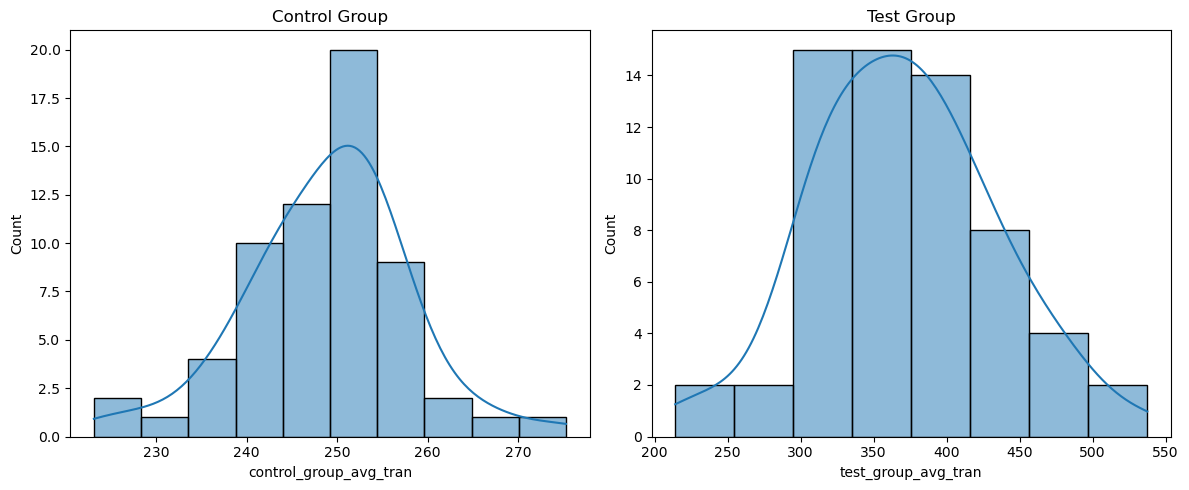

In [93]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Histogram for control group
sns.histplot(results_df['control_group_avg_tran'], kde=True, ax=axes[0])
axes[0].set_title('Control Group')

# Histogram for test group
sns.histplot(results_df['test_group_avg_tran'], kde=True, ax=axes[1])
axes[1].set_title('Test Group')

# Adjust layout
plt.tight_layout()
plt.show()

In [94]:
# A/B Testing 

control_mean = results_df['control_group_avg_tran'].mean()
control_std = results_df['control_group_avg_tran'].std()

control_mean, control_std

(np.float64(248.94129032258064), 9.137869049553624)

In [95]:
test_mean = results_df['test_group_avg_tran'].mean()
test_std = results_df['test_group_avg_tran'].std()

test_mean, test_std

(np.float64(370.5364516129033), 63.25415113953285)

In [96]:
sample_size = results_df.shape[0]
sample_size

62

In [97]:
a = (control_std**2/sample_size)
b = (test_std**2/sample_size)

z_score = (test_mean - control_mean)/np.sqrt(a+b)

z_score

np.float64(14.980903070990523)

In [98]:
z_critical = st.norm.ppf(1-alpha)

z_critical

np.float64(1.644853626951472)

In [99]:
z_score > z_critical

np.True_

### Hypothesis Test Result

Since the **calculated Z-score** is higher than the **critical Z-value**, we **reject the null hypothesis (H₀)**.  

**Interpretation:**  
The average transaction amount of the **test group** is significantly higher than that of the **control group**, suggesting that offering the new credit card has a positive effect on spending.


In [100]:
# Testing using P-Value 

p_value = 1- st.norm.cdf(z_score)
p_value

np.float64(0.0)

The p-value is approximately 0.0, indicating extremely strong evidence against the null hypothesis.  
We reject H₀ and conclude that offering the new credit card significantly increases the average transaction amount.


In [101]:
# Confidence Interval 

diff = test_mean - control_mean

x = test_std**2/sample_size
y = control_std**2/sample_size

standard_error = np.sqrt(x+y)

lower = diff - 1.96*standard_error
upper = diff + 1.96*standard_error

lower, upper

(np.float64(105.686473075756), np.float64(137.50384950488933))

### Confidence Interval

The 95% confidence interval for the increase in average transaction amount due to the new credit card is approximately **$106 to $138** per customer.  

Since the interval does **not include 0**, this indicates a statistically significant increase, confirming that the new credit card positively impacts spending.


In [ ]:
# Using Ready Made API call¶

In [105]:
z_statistic, p_values = sm.stats.ztest(
    results_df['test_group_avg_tran'],
    results_df['control_group_avg_tran'],
    alternative='larger')

z_statistic, p_values

(np.float64(14.980903070990523), np.float64(4.893899020400689e-51))